# Escalonamento e normalização

**Tema:** Preparação de Dados › Encoding, Escala e Vazamento de Dados

`StandardScaler`, `MinMaxScaler` e `RobustScaler` produzem resultados bem
diferentes na presença de outliers — este notebook mede essa diferença
diretamente, e confirma, com um experimento, que árvores são de fato
invariantes a escalonamento enquanto k-NN não é.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

rng = np.random.default_rng(25)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Os três escalonadores no mesmo dado com outliers

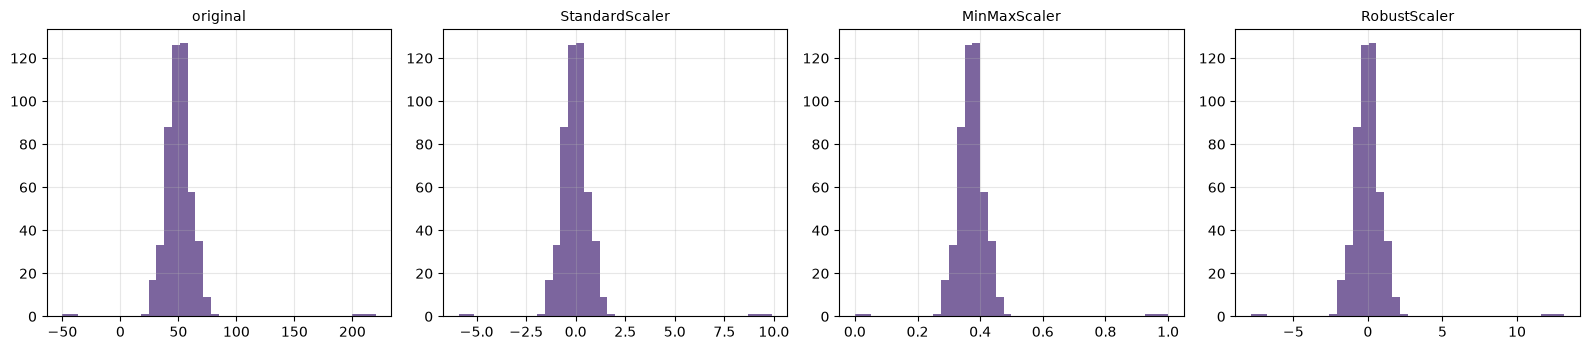

In [2]:
n = 500
dados_normais = rng.normal(50, 10, n - 5)
outliers = np.array([200, 210, -50, 220, -40])  # 5 outliers genuínos
dados = np.concatenate([dados_normais, outliers]).reshape(-1, 1)

escalonadores = {
    "original": dados.ravel(),
    "StandardScaler": StandardScaler().fit_transform(dados).ravel(),
    "MinMaxScaler": MinMaxScaler().fit_transform(dados).ravel(),
    "RobustScaler": RobustScaler().fit_transform(dados).ravel(),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (nome, v) in zip(axes, escalonadores.items()):
    ax.hist(v, bins=40, color=ROXO, alpha=0.8)
    ax.set_title(nome, fontsize=10)
plt.tight_layout(); plt.show()

## 2. Onde os 495 pontos "normais" acabam depois de cada escalonador

In [3]:
print(f"{'escalonador':<16s} {'faixa dos 495 pontos normais':>32s} "
      f"{'faixa TOTAL (com outliers)':>30s}")
print("-" * 82)
for nome, v in escalonadores.items():
    normais_escalonados = v[:-5]
    print(f"{nome:<16s} [{normais_escalonados.min():>8.3f}, {normais_escalonados.max():>8.3f}]"
          f"{'':>10s}[{v.min():>8.3f}, {v.max():>8.3f}]")

escalonador          faixa dos 495 pontos normais     faixa TOTAL (com outliers)
----------------------------------------------------------------------------------
original         [  20.779,   83.700]          [ -50.000,  220.000]
StandardScaler   [  -1.763,    1.920]          [  -5.906,    9.898]
MinMaxScaler     [   0.262,    0.495]          [   0.000,    1.000]
RobustScaler     [  -2.325,    2.569]          [  -7.830,   13.171]


**O efeito do `MinMaxScaler` fica evidente:** os 495 pontos "normais" (que
deveriam ocupar a maior parte da faixa útil) ficam espremidos numa fatia
minúscula de $[0,1]$, porque a escala inteira é ancorada nos 5 outliers.
`RobustScaler`, usando mediana e IQR, ignora os outliers ao definir a escala
— os pontos normais ocupam uma faixa parecida com a do `StandardScaler`.

## 3. k-NN é sensível à escala; árvore não

Duas features de escalas muito diferentes, ambas informativas. Comparamos
k-NN (baseado em distância) e uma árvore, com e sem padronização.

In [4]:
n = 800
x1 = rng.normal(0, 1, n)          # escala pequena
x2 = rng.normal(0, 1000, n)       # escala grande
alvo = (0.8 * x1 + 0.0006 * x2 + rng.normal(0, 0.5, n) > 0).astype(int)

X_bruto = np.column_stack([x1, x2])
X_padronizado = StandardScaler().fit_transform(X_bruto)

print(f"{'modelo':<24s} {'features BRUTAS':>18s} {'features PADRONIZADAS':>24s}")
print("-" * 68)
for nome, modelo in [("k-NN (k=15)", KNeighborsClassifier(n_neighbors=15)),
                     ("Árvore (profund. 4)", DecisionTreeClassifier(max_depth=4, random_state=0))]:
    auc_bruto = cross_val_score(modelo, X_bruto, alvo, cv=5, scoring="roc_auc").mean()
    auc_padronizado = cross_val_score(modelo, X_padronizado, alvo, cv=5, scoring="roc_auc").mean()
    print(f"{nome:<24s} {auc_bruto:>18.4f} {auc_padronizado:>24.4f}")

modelo                      features BRUTAS    features PADRONIZADAS
--------------------------------------------------------------------
k-NN (k=15)                          0.7403                   0.9442
Árvore (profund. 4)                  0.9187                   0.9187


**Leitura esperada:** o k-NN melhora substancialmente com padronização —
sem ela, `x2` (escala ~1000x maior) domina completamente o cálculo de
distância, tornando `x1` quase irrelevante mesmo que ambas carreguem sinal.
A árvore deve ter desempenho praticamente idêntico nos dois casos — ela
escolhe pontos de corte por variável, e reescalar uma variável não muda a
ordem relativa dos seus valores, só a régua usada para medi-la.

## 4. A armadilha do vazamento no escalonamento

`fit_transform` no dataset inteiro (antes do split) usa a média e o desvio
de TODOS os dados, incluindo o que deveria ser teste — a mesma lógica de
vazamento de pré-processamento vista nos módulos anteriores.

In [5]:
from sklearn.model_selection import train_test_split

X_treino, X_teste = train_test_split(X_bruto, test_size=0.3, random_state=0)

# ERRADO
scaler_errado = StandardScaler().fit(X_bruto)  # viu o dataset INTEIRO
media_vazada = scaler_errado.mean_

# CERTO
scaler_certo = StandardScaler().fit(X_treino)  # só viu o treino
media_correta = scaler_certo.mean_

print(f"média usada (fit no dataset INTEIRO): {media_vazada}")
print(f"média usada (fit só no TREINO)      : {media_correta}")
print(f"\ndiferença: {np.abs(media_vazada - media_correta)}")
print("\nA diferença numérica pode ser pequena com split aleatório grande, mas o")
print("princípio vale sempre: o teste representa dados que, na produção real, o")
print("modelo ainda não viu no momento de calcular qualquer estatística de ajuste.")

média usada (fit no dataset INTEIRO): [ 0.04373547 25.44443014]
média usada (fit só no TREINO)      : [ 0.07381903 23.37951069]

diferença: [0.03008357 2.06491945]

A diferença numérica pode ser pequena com split aleatório grande, mas o
princípio vale sempre: o teste representa dados que, na produção real, o
modelo ainda não viu no momento de calcular qualquer estatística de ajuste.


## O que levar deste notebook

- `MinMaxScaler` é o mais sensível a outliers — um único valor extremo
  redefine toda a escala. `RobustScaler` (mediana/IQR) ignora esse efeito.
- Métodos baseados em distância (k-NN, k-means, SVM) e em gradiente
  (regressão, redes neurais) exigem escalonamento; árvores e seus ensembles
  não precisam.
- `fit` do escalonador deve acontecer só no treino — o mesmo princípio de
  todos os outros transformadores vistos neste tema.

→ Próximo: **Vazamento de dados**, consolidando a taxonomia completa e a
solução estrutural com `Pipeline`.